In [1]:
import numpy as np
from numpy import datetime64 as dt64
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Rectangle

import cmocean
from glob import glob
from cartopy.crs import Geodetic
import warnings

import pandas as pd
import geopandas as gpd
import seaborn as sns

warnings.simplefilter('ignore')

# Set Parameters

In [2]:
# Paths
project_folder_path = Path('/gxfs_work/geomar/smomw597/2025_copepods/')
sample_points_file_path = project_folder_path \
    / 'output/sample_points_valid_count.geojson'
connectivity_matrix_folder_path = project_folder_path \
    / 'output/connectivity_matrices/'
figure_output_path = project_folder_path / 'Figures/connectivity_matrices/'

In [3]:
# Load the sample points
sample_points = gpd.read_file(sample_points_file_path)
sample_ids = sample_points.location_id

In [4]:
particle_count_column_names = [
	f'valid_particles_{year}' 
	for year 
	in range(2016, 2025)
	]
sample_points['total_valid_particles'] = (
	sample_points
	.loc[:, particle_count_column_names]
	.sum(axis=1)
)

In [5]:
digital_sample_ids = sample_ids.where(sample_points.sample_kind == 'digital')\
    .dropna().tolist()
non_genetic_sample_ids = sample_ids.where(sample_points.genomic_data == False)\
    .dropna().tolist()
north_sea_sample_ids = sample_ids.where(sample_points.sea == 'northsea')\
    .dropna().tolist()
genetic_sample_ids = sample_ids.where(sample_points.genomic_data == True)\
    .dropna().tolist()

In [6]:
sample_point_ids = sample_points.location_id.tolist()
n_years = len(np.arange(2016,2025))
days_per_year = (dt64('2016-11-01') - dt64('2016-06-01')).astype('int')
timesteps_per_day = 24*4
days_juvenile = 10
days_life = 28
days_adult = days_life - days_juvenile
n_particles_per_release = 1000

total_particles_per_site = days_per_year * n_years * n_particles_per_release
max_observation_per_particle = days_adult * timesteps_per_day

# Functions

In [7]:
def drop_rows_and_cols(matrix, labels):
        return matrix.drop(columns=labels, index=labels, errors='ignore')

In [8]:
def define_color_map(
	cmap_input='coolwarm', discrete_color_map=False, 
	vmin=None, vmax=None,
	):
	if isinstance(cmap_input, str):
		cmap = mpl.colormaps.get_cmap(cmap_input)
	elif isinstance(cmap_input, type(cmocean.cm.haline)):
		cmap = cmap_input
	elif not isinstance(cmap_input, type(cmocean.cm.haline)):
		return print('Please input colormap or colormap name (str).')

	vmax_log10 = 10**np.ceil(np.log10(vmax))
	vmin_log10 = 10**np.floor(np.log10(vmin))
	sample_steps = vmax_log10-vmin_log10
	bounds = np.arange(vmin_log10, vmax_log10+1)
	fmt = '.0f'
	norm = Normalize(vmin=vmin, vmax=vmax)
	# resample the colormap into the amount of discrete steps 
	# of difference between the vmin_log10 and vmax_log10 in power of 10
	magnitude_difference = (
		np.log10(vmax_log10) - np.log10(vmin_log10)
		).astype(int) 
	if (magnitude_difference >2):
		while magnitude_difference > 10:
			magnitude_difference = np.ceil(magnitude_difference/2).astype(int)
		sample_steps = magnitude_difference
		bounds = np.logspace(
			np.log10(vmin_log10), np.log10(vmax_log10), magnitude_difference+1
			)
		fmt = '.0e'
		norm = LogNorm(vmin=vmin_log10, vmax=vmax_log10,)
	else:
		sample_steps = vmax-vmin
	if discrete_color_map:
		cmap = cmap.resampled(sample_steps)
		# force the first color entry to be invisible
		cmap.set_under(color='#00000000') 
	return cmap, bounds, fmt, norm

In [9]:
def highlight_col(ax, idx, length):
	return ax.add_patch(
		Rectangle(
			(idx, 0), 1, length,
			fill=True, color='lightgray',
			lw=0.5, alpha=0.3,
			zorder=0,
			)
		)
def highlight_row(ax, idx, length):
	return ax.add_patch(
		Rectangle(
			(0, idx), length, 1,
			fill=True, color='lightgray',
			lw=0.5, alpha=0.3, 
			zorder=0,
			)
		)

def highlight_cells(ax):
	length = len(ax.get_xticklabels())
	geneticSamples_list = genetic_sample_ids
	for idx, site_name in enumerate(ax.get_xticklabels()):
		if site_name.get_text() in geneticSamples_list:
			highlight_col(ax, idx, length)
			highlight_row(ax, idx, length)
	return ax

In [10]:
def build_ax(
	ax, 
	fontsize=10, labelpad=15,
	xlabelposition='top', highlight_genetic=False,
	):
	ax.xaxis.set_label_position(xlabelposition)  
	pad = 5
	if xlabelposition == 'top':
		ax.tick_params(
			grid_linewidth=0,
			labelsize=fontsize, 
			labelbottom=False,
			labeltop=True, 
			size=0,
			pad=pad,
		)
	if highlight_genetic:
		for x_tick, y_tick in zip(ax.get_xticklabels(), ax.get_yticklabels()):
			if x_tick.get_text() in genetic_sample_ids:
				x_tick.set_fontweight('bold')
				y_tick.set_fontweight('bold')
	ax.set_yticklabels(ax.get_yticklabels(), rotation=0,)
	ax.set_xticklabels(ax.get_xticklabels(), rotation=90,)
	ax.set_ylabel('Source Stations', size=fontsize, labelpad=labelpad)
	ax.set_xlabel('Target Stations', size=fontsize, labelpad=labelpad)
	return ax

In [11]:
def show_connectivity_matrix(
	matrix, 
	cmap='coolwarm',
	highlight_genetic=False,
	title='Connectivity Matrix',
	cbtitle=None,
	discrete_color_map=False,
	fontsize=10,
	titlesize=12,
	annot=True,
	fmt = '.0e',
	draw_cbar=True,
	figsize=(7, 7),
	file_name=None
	):
	vmax = matrix.max(axis=None)
	vmin = matrix.where(matrix != 0).min(axis=None)
	cmap, bounds, fmt, norm = define_color_map(
		discrete_color_map=discrete_color_map,
		vmax=vmax,
		vmin=vmin,
		cmap_input=cmap,
	)
	mask = matrix == 0
	cbar_kws = {
		'label': cbtitle, 'norm': norm, 'format': '%'+fmt, 'ticks': bounds
		}
	if draw_cbar:
		fig, (ax, cbar_ax) = plt.subplots(
			nrows=1, ncols=2, 
			figsize=(8, 7), 
			gridspec_kw={'width_ratios': (0.9, 0.05)},
			)
	else:
		fig, ax = plt.subplots(nrows=1, ncols=1, figsize=figsize)
		cbar_ax = ax
	fig.suptitle(title, size=titlesize)
	sns.heatmap(
		matrix, mask=mask, cmap=cmap, ax=ax, 
		linewidths=0.5, linecolor='lightgrey',
		norm=norm, square=True,
		annot=annot, fmt=fmt, annot_kws={'size': fontsize},
		cbar=draw_cbar, cbar_kws=cbar_kws, cbar_ax=cbar_ax,
	)
	if draw_cbar:
		cbar_ax.minorticks_off()
	if highlight_genetic:
		ax = highlight_cells(ax)
	ax = build_ax(ax, fontsize=fontsize, highlight_genetic=highlight_genetic)
	plt.tight_layout()
	if file_name is not None:
		plt.savefig(Path(figure_output_path, file_name), format='pdf')
	return plt.show()

# Connectivity Matrices

In [12]:
cm_total = 0
for matrix_link in sorted(connectivity_matrix_folder_path.glob(f'*')):
    cm_total += pd.read_csv(matrix_link, index_col=0)

In [13]:
cm_norm_rel = pd.DataFrame().reindex_like(cm_total)
sample_points = sample_points.set_index('location_id_old', drop=False)
for target_location in cm_norm_rel:
	area = sample_points.loc[target_location].sea_surface_area
	count = cm_total.loc[:, target_location]
	total = sample_points.total_valid_particles
	relative_count = (count/area/total)
	cm_norm_rel.loc[:, target_location] = relative_count

In [14]:
generation_count = 1
cm_multigen = cm_norm_rel.copy()
gen_count_matrix = cm_multigen.where(cm_multigen==0, generation_count)
for generation_count in range(2, 25):
	cm_multigen = cm_norm_rel.dot(cm_multigen)
	gen_count_mask = ((gen_count_matrix != 0) | (cm_multigen==0))
	gen_count_matrix = gen_count_matrix.where(gen_count_mask, generation_count)
	if gen_count_matrix.min(axis=None) > 0:
		break

In [15]:
cm_norm_rel.to_csv(connectivity_matrix_folder_path / 'connectivity_matrix.csv')
cm_multigen.to_csv(connectivity_matrix_folder_path \
	/ 'multigeneration_connectivity_matrix.csv')
gen_count_matrix.to_csv(connectivity_matrix_folder_path \
	/ 'generation_count_matrix.csv')

In [16]:
cm_norm_rel_genetic = drop_rows_and_cols(cm_norm_rel, non_genetic_sample_ids)
cm_norm_rel_sampled = drop_rows_and_cols(cm_norm_rel, digital_sample_ids)
cm_norm_rel_baltic = drop_rows_and_cols(cm_norm_rel, north_sea_sample_ids)
cm_norm_rel_baltic_genetic = drop_rows_and_cols(
	cm_norm_rel,
	(non_genetic_sample_ids + north_sea_sample_ids),
	)
cm_norm_rel_baltic_sampled = drop_rows_and_cols(
	cm_norm_rel,
	(digital_sample_ids + north_sea_sample_ids),
	)

In [17]:
generation_matrix_genetic = drop_rows_and_cols(
	gen_count_matrix, non_genetic_sample_ids
	)
generation_matrix_sampled = drop_rows_and_cols(
	gen_count_matrix, digital_sample_ids
	)
generation_matrix_baltic = drop_rows_and_cols(
	gen_count_matrix, north_sea_sample_ids
	)
generation_matrix_baltic_genetic = drop_rows_and_cols(
	gen_count_matrix,
	(north_sea_sample_ids + non_genetic_sample_ids)
	)
generation_matrix_baltic_sampled = drop_rows_and_cols(
	gen_count_matrix,
	(north_sea_sample_ids + digital_sample_ids)
	)

In [18]:
cm_multigen_genetic = drop_rows_and_cols(cm_multigen, non_genetic_sample_ids)
cm_multigen_sampled = drop_rows_and_cols(cm_multigen, digital_sample_ids)
cm_multigen_baltic = drop_rows_and_cols(cm_multigen, north_sea_sample_ids)
cm_multigen_baltic_genetic = drop_rows_and_cols(
	cm_multigen_baltic,
	(north_sea_sample_ids + non_genetic_sample_ids),
	)
cm_multigen_baltic_sampled = drop_rows_and_cols(
	cm_multigen_baltic,
	(north_sea_sample_ids + digital_sample_ids),
	)

# Figures

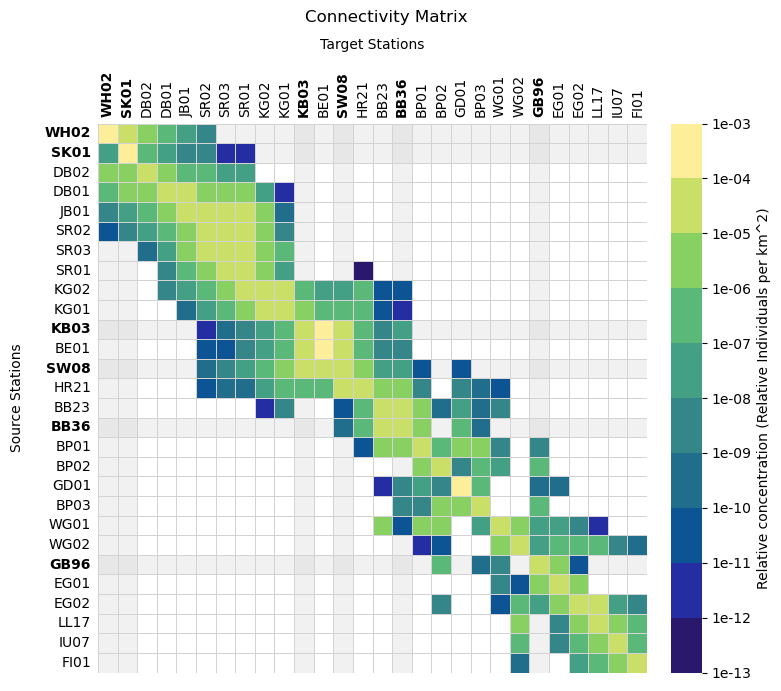

In [41]:
# relative single generation Connectivity Matrix area normalized 
show_connectivity_matrix(
	cm_norm_rel, 
	cbtitle='Relative concentration (Relative Individuals per km^2)',
	discrete_color_map=True, 
	annot=False, 
	highlight_genetic=True, 
	cmap=cmocean.cm.haline,
	# file_name='connectivity_matrix_all.pdf',
)

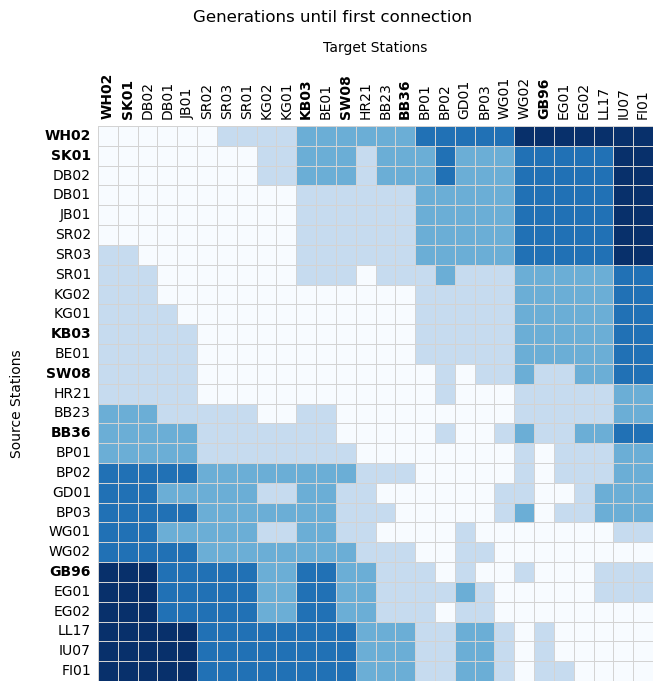

In [28]:
# Matrix of all stations that shows the generations until connetion at least one connetion
show_connectivity_matrix(
	gen_count_matrix, 
	cbtitle='Generations until connected',
	discrete_color_map=True, 
	cmap='Blues', 
	draw_cbar=False, 
	annot=False, 
	highlight_genetic=True,
	title='Generations until first connection',
	# file_name='generation_matrix_all.pdf',
)

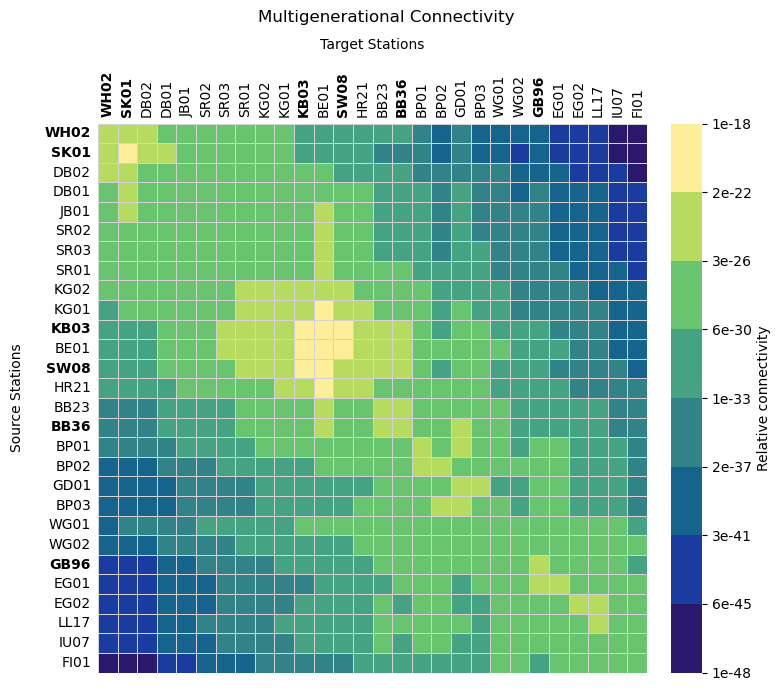

In [34]:
# Multigenerational connectivity matrix of all stations
show_connectivity_matrix(
	cm_multigen, 
	cbtitle='Relative connectivity',
	discrete_color_map=True, 
	cmap=cmocean.cm.haline, 
	draw_cbar=True, 
	annot=False, 
	highlight_genetic=True,
	title='Multigenerational Connectivity',
	# file_name='multigeneration_connectivity_matrix_all.pdf',
)